Example Plots for Simulated Annealing

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
num_runs = 10

In [70]:
brute_force_data_paths = [
    'data/brute_force/candidate_space_1048576_instances_1_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_9_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_33_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_42_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_57_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_99_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_100_seed_2026-03-28_15-52-55.csv',
    'data/brute_force/candidate_space_1048576_instances_110_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_808_seed_2026-03-28_15-53-27.csv',
    'data/brute_force/candidate_space_1048576_instances_5004_seed_2026-03-28_15-16-30.csv',
]
boundss = [
    [(0, 4)] * 10
] * len(brute_force_data_paths)

In [71]:
import pandas as pd

brute_force_data = [pd.read_csv(p) for p in brute_force_data_paths]

In [73]:
from cl_optimizer import SimulatedAnnealing
sim_annss = [[
        SimulatedAnnealing(
        lookup_table=data,
        bounds=bounds,
    ) for _ in range(num_runs)
] for data, bounds in zip(brute_force_data, boundss)]

In [74]:
import numpy as np
# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 100
end_temp = 1
max_temp_iterations = 80

def execute_sim_ann(df_id: int, sim_ann: SimulatedAnnealing, temp_iterations: list[int]) -> np.ndarray:
    optima = []
    for iterations in temp_iterations:
        print(f"Temp. Iterations {iterations}")
        temp_schedule = SimulatedAnnealing.geometric_temp_schedule(init_temp, end_temp, iterations)
        _, loss = sim_ann.optimize(
            temp_schedule=temp_schedule,
            verbose=False
        )
        optima.append(loss)

    return np.concat(([df_id], temp_iterations, optima))

In [77]:
from joblib import Parallel, delayed
from parallelization import construct_parallelization_arg_list
from parallelization import extract_sorted_losses_and_temps

sorted_tempss = []
sorted_lossess = []
for sim_anns in sim_annss:
    arg_list = construct_parallelization_arg_list(sim_anns, depth=max_temp_iterations, step=10, batch_size=8)

    print(f"Preparing to execute {len(arg_list)} in parallel.")
    results = np.array(
        Parallel(n_jobs=-1, verbose=11)(
        delayed(execute_sim_ann)(s_id, sim_ann, temp_iterations) for (s_id, sim_ann), temp_iterations in arg_list)
    )

    sorted_temps, sorted_losses = extract_sorted_losses_and_temps(results)
    sorted_tempss.append(sorted_temps)
    sorted_lossess.append(sorted_losses)

Preparing to execute 10 in parallel.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   41.9s remaining:  2.8min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   42.4s remaining:  1.7min
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   43.0s remaining:  1.1min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   43.2s remaining:   43.2s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   44.2s remaining:   29.5s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   44.6s remaining:   19.1s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   44.6s remaining:   11.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Preparing to execute 10 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:  1.1min remaining:  4.5min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  1.1min remaining:  2.7min
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:  1.2min remaining:  1.7min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  1.2min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:  1.2min remaining:   47.8s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  1.2min remaining:   30.9s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:  1.3min remaining:   18.8s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Preparing to execute 10 in parallel.


...

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   38.6s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   39.1s remaining:  2.6min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   39.5s remaining:  1.5min
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   39.6s remaining:   59.4s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   40.4s remaining:   40.4s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   40.5s remaining:   27.0s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   41.0s remaining:   17.5s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   41.3s remaining:   10.3s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Preparing to execute 10 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   39.1s remaining:  2.6min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   39.6s remaining:  1.5min
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   40.0s remaining:  1.0min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   40.3s remaining:   40.3s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   40.9s remaining:   27.2s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   41.5s remaining:   17.7s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   41.7s remaining:   10.3s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Preparing to execute 10 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   39.6s remaining:  2.6min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   40.0s remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   40.2s remaining:  1.0min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   40.7s remaining:   40.7s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   41.8s remaining:   27.8s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   41.8s remaining:   17.9s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   42.1s remaining:   10.5s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.0min finished


In [140]:
from datetime import datetime

cols = [f'loss (temperature={int(temp)})' for temp in sorted_tempss[0][0]]
df = pd.DataFrame(sorted_lossess, columns=cols)
df["data path"] = np.repeat(brute_force_data_paths, num_runs)
df.to_csv(f'data/simulated_annealing/summary_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv')

In [141]:
from metrics import raar

avg_loss_runs = [sorted_losses.mean(axis=0) for sorted_losses in sorted_lossess]
raars = np.array([[raar(avg, brute_force_data[i]['loss']) for avg in avg_loss] for i, avg_loss in enumerate(avg_loss_runs)])
mean_raar = raars.mean(axis=0)
std_raar = raars.std(axis=0)

<ErrorbarContainer object of 3 artists>

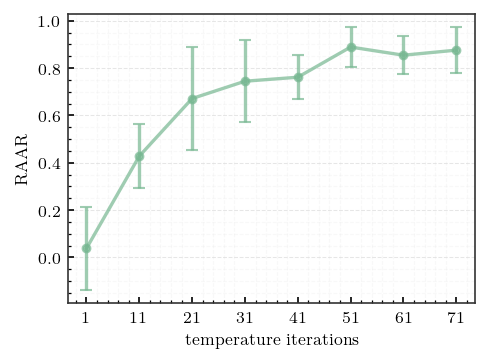

In [142]:
import styling
import seaborn as sns
styling.set_my_style()

df = pd.DataFrame()
df["temperature iterations"] = sorted_tempss[0][0, :].astype(int)
df["RAAR"] = mean_raar
df["RAAR_std"] = std_raar

palette = styling.shades(6, 4)[1:]
palette = sns.color_palette("crest", 5)


fig, ax = styling.subplots(figsize=(3.5, 2.5))

line = sns.pointplot(
    data=df,
    x="temperature iterations",
    y="RAAR",
    errorbar=None,
    capsize=0.2,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax.errorbar(
    x=line.get_lines()[0].get_xdata(),
    y=df["RAAR"],
    yerr=df["RAAR_std"],
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)



In [148]:
min_losses = [data['loss'].min() for data in brute_force_data]
min_loss_candidates = np.array([data[data['loss'] == min_loss]['candidate'] for data, min_loss in zip(brute_force_data, min_losses)])

In [149]:
min_loss_candidates

array([['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]']], dtype=object)

In [150]:
optimal_candidates_found = [np.count_nonzero(sorted_losses == min_loss, axis=0) for sorted_losses, min_loss in zip(sorted_lossess, min_losses)]
p_star = [optimal_found / sorted_losses.shape[1] for optimal_found, sorted_losses in zip(optimal_candidates_found, sorted_lossess)]

In [152]:
from metrics import min_tts
tts_ps = np.array([min_tts(p_s, return_tts_p=True)[2] for p_s in p_star])

[4605168. 4605168. 4605168. 4605168. 4605168. 4605168. 4605168. 4605168.]
[0. 0. 0. 0. 0. 0. 0. 0.]


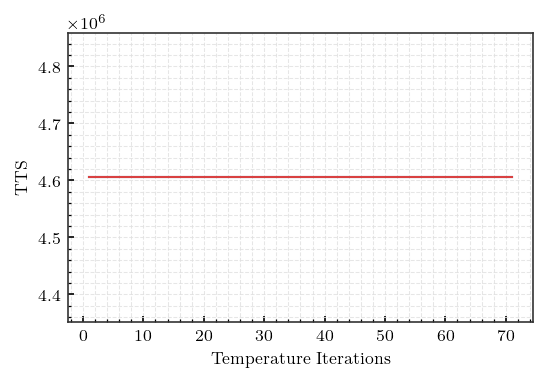

In [157]:
from matplotlib import pyplot as plt

mean_tts_ps = tts_ps.mean(axis=0)
std_tts_ps = tts_ps.std(axis=0)

plt.plot(
    sorted_tempss[0][0, :],
    mean_tts_ps,
)

plt.errorbar(
    sorted_tempss[0][0, :],
    y=mean_tts_ps,
    yerr=std_tts_ps,
)
plt.ylabel('TTS')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)